In [1]:
import sys
sys.path.append("..")
import os
import itertools
import numpy as np
import torch
import pickle
import scipy.stats as st
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from decompTCR.tools._basis_decomposition.run_batch import compute_basis_decomposition, _plot_basis, get_basis
from decompTCR.tools._basis_decomposition.inference  import InferenceMode, get_inference_guide
from decompTCR.tools._basis_decomposition.model_batch import BasisDecomposition, BasisDecomposition_Evaluate


import pyro
from pyro.infer import Predictive, Trace_ELBO, Trace_ELBO, SVI
from sklearn.preprocessing import MaxAbsScaler, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sknetwork.clustering import Louvain
from sklearn.metrics import r2_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from umap import UMAP

from utils import display_cat, clear_val_params, summary, process_data, find_sequence_rows_regex, clustermap, bernoulli_downsample

## Toy Dataset Generation

In [2]:
#This is purely for figure generating the
sin_f = np.sin(np.linspace(0, 6.28, 181)*2)+1
inc_f = 1*np.linspace(0,1,181)
dec_f = -1*np.linspace(0,1,181)+1
sigp_f = 1/(1 + np.exp(-np.linspace(-10,20,181))) 
sign_f = -1/(1 + np.exp(-np.linspace(-5,20,181))) + 1 

sin_f = (sin_f - np.min(sin_f))/np.max(sin_f)
sigp_f = (sigp_f - np.min(sigp_f))/np.max(sigp_f) 
sign_f = (sign_f - np.min(sign_f))/np.max(sign_f)

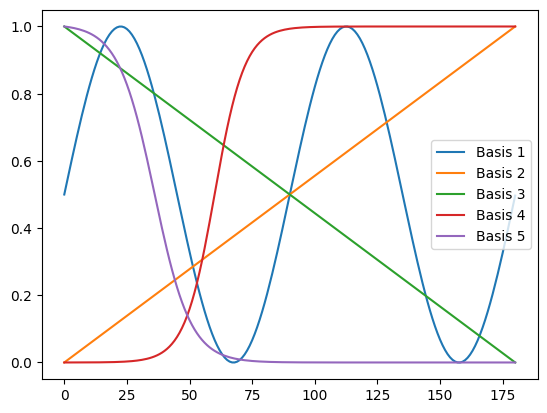

In [3]:
#Plotting the chosen basis
plt.plot(sin_f)
plt.plot(inc_f)
plt.plot(dec_f)
plt.plot(sigp_f)
plt.plot(sign_f)
plt.legend(["Basis 1", "Basis 2", "Basis 3", "Basis 4", "Basis 5"])

In [38]:
#Sample the weights for each basis randomly from a dirichlet distribution and clonerate new functions
g1_weights = (0.199, 0.45, 0.2, 0.001, 0.25)
g2_weights = (0.1, 0.1, 0.10, 0.60, 0.10)
random_weights_g1 = np.random.dirichlet(g1_weights, 2500)
random_weights_g2 = np.random.dirichlet(g2_weights, 100)

new_functions_g1 = [random_weights_g1[i,0]*sin_f + random_weights_g1[i,1]*inc_f + random_weights_g1[i,2]*dec_f + random_weights_g1[i,3]*sigp_f + random_weights_g1[i,4]*sign_f for i in range(len(random_weights_g1[:,0]))] 
new_functions_g1 = np.array(new_functions_g1)

new_functions_g2 = [random_weights_g2[i,0]*sin_f + random_weights_g2[i,1]*inc_f + random_weights_g2[i,2]*dec_f + random_weights_g2[i,3]*sigp_f + random_weights_g2[i,4]*sign_f for i in range(len(random_weights_g2[:,0]))] 
new_functions_g2 = np.array(new_functions_g2)

#Now we downsample the functions to make it similar to real data. We use a bernoulli downsampling scheme where as time goes on, the probability of observing a point decreases from 5% to .1%.
new_functions_ds_g1 = bernoulli_downsample(new_functions_g1, 0.05, 0.001)
new_functions_ds_g2 = bernoulli_downsample(new_functions_g2, 0.05, 0.001)

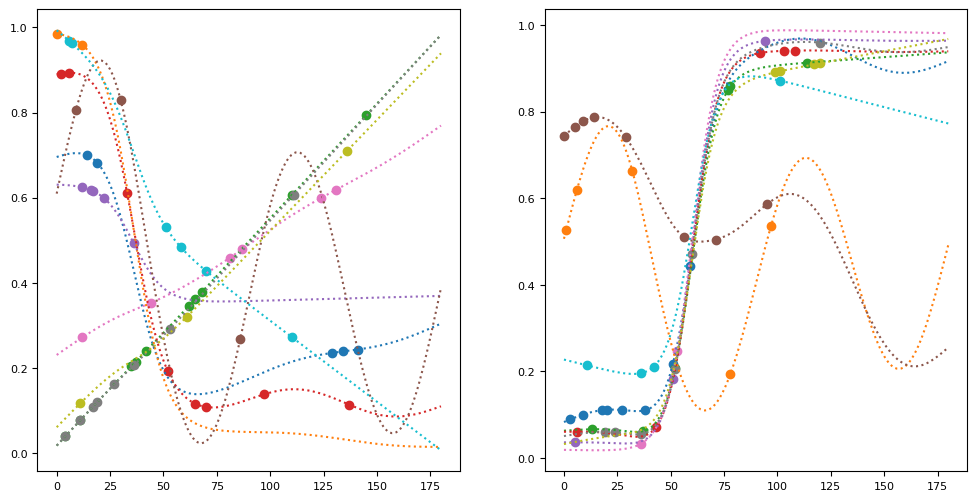

In [39]:
fig, axs = plt.subplots(1,2, figsize = (12,6))
times = np.arange(0,181,1)
for i in range(10):
    axs[0].scatter(times,new_functions_ds_g1[i,:])
    axs[0].plot(times, new_functions_g1[i,:], linestyle = ":")
    
for i in range(10):
    axs[1].scatter(times,new_functions_ds_g2[i,:])
    axs[1].plot(times, new_functions_g2[i,:], linestyle = ":")

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


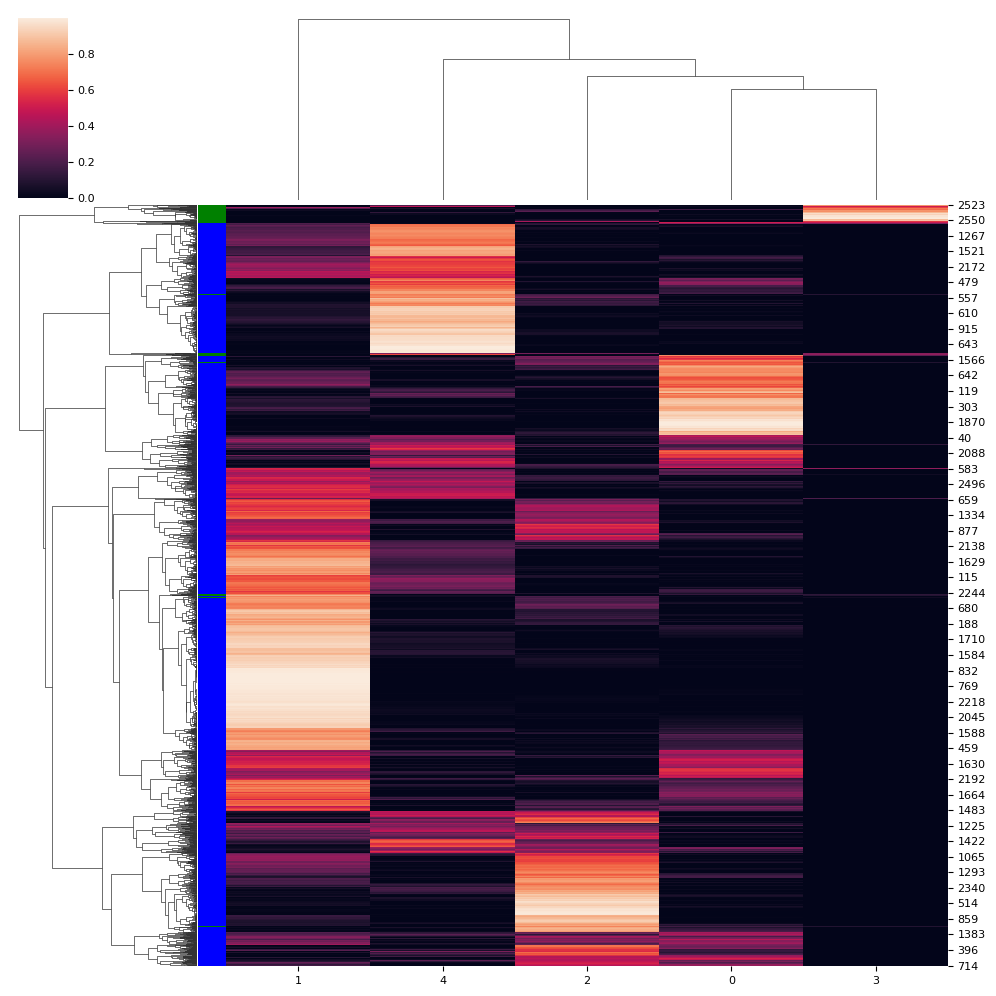

In [40]:
true_props = {'g1 weights': g1_weights, 'g2 weights': g2_weights}
true_props_df = pd.DataFrame(true_props).reset_index().melt(id_vars = 'index')

#Uncomment to plot true basis weights and random weights clustermap based on true weights

#sns.catplot(data = true_props_df, x = 'index', y = 'value', kind = 'bar', hue = 'variable' , height = 4, aspect = 1.5)
#plt.title("True Basis Weights")

random_weights = np.concatenate([random_weights_g1,random_weights_g2],axis = 0)
labels = np.array(['b']*2500 + ['g']*100)

sns.clustermap(random_weights, row_colors=labels)

## Preprocess the Data
The matrix for input must be n clones by t timepoints, where nan values are at places where their are missing timepoints or are points you wish to impute.

In [41]:
new_functions_ds = np.concatenate([new_functions_ds_g1, new_functions_ds_g2], axis = 0)
new_functions_ds = torch.FloatTensor(new_functions_ds)

train_a_idx, val_a_idx = train_test_split(np.arange(new_functions_ds.shape[0]), test_size = 0.1)
clone_patterns_padded_allo_train = new_functions_ds[train_a_idx,:]
clone_patterns_padded_allo_val = new_functions_ds[val_a_idx,:]

new_functions = np.concatenate([new_functions_g1, new_functions_g2], axis = 0)
gt = torch.FloatTensor(new_functions)
gt_train = gt[train_a_idx,:]
gt_val = gt[val_a_idx,:]

In [54]:
n_basis = 10
n_iter = 2_000
show_basis = True
lr = 1e-2
beta_prior = 0.001 #Low beta prior to encourage sparsity
weight_decay = 1e-7
inverse_length_scale = 6 #Higher value = more complex basis functions
times_padded = np.linspace(-1,1,181)

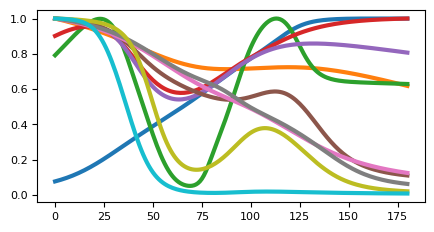

Loss: 99748.5 - Relative Error: 0.02, - Val_loss: 0.11: 100%|██████████| 2000/2000 [03:23<00:00,  9.84it/s] 


In [55]:
trajectory_model_a, guide_a, times_a, samples_a, clone_scales_a, losses_a, rel_loss_a, val_loss_a = compute_basis_decomposition(
clone_patterns_padded_allo_train.numpy(),
InferenceMode.GAUSSIAN_BETA_ONLY, # You can set this to POINT_ESTIMATE, GUASSIAN, GUASSIAN_BASIS_ONLY, depending on if you want to infer uncertainty in betas, basis functions, both, or neither. 
n_basis=n_basis,
n_iter=n_iter,
batch_size=None,
lr=lr,
beta_prior=beta_prior,
weight_decay = weight_decay,
inverse_length_scale = inverse_length_scale,
seed=1,
normalized_mode=True,
times = np.linspace(-1,1,181),
plot_every_k_epochs=100,
clone_patterns_val= clone_patterns_padded_allo_val.numpy()
)

## Model Evaluation

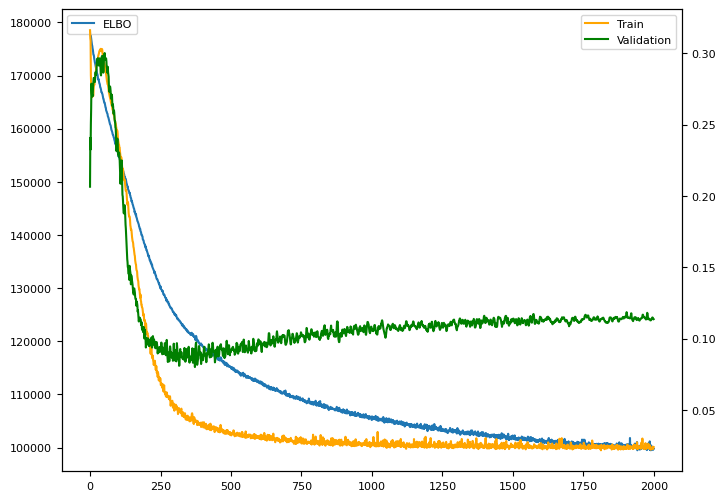

In [56]:
clone_patterns_mean = clone_patterns_padded_allo_train.nanmean(axis = -1, keepdim= True)

ig, ax = plt.subplots(1,1, figsize = (8,6))
ax.plot(losses_a)
ax2 = ax.twinx()
ax2.plot(rel_loss_a, color = "orange")
ax2.plot(val_loss_a, color = "green")
ax.legend(["ELBO"], loc = "upper left")
ax2.legend(["Train", "Validation"])
plt.show()


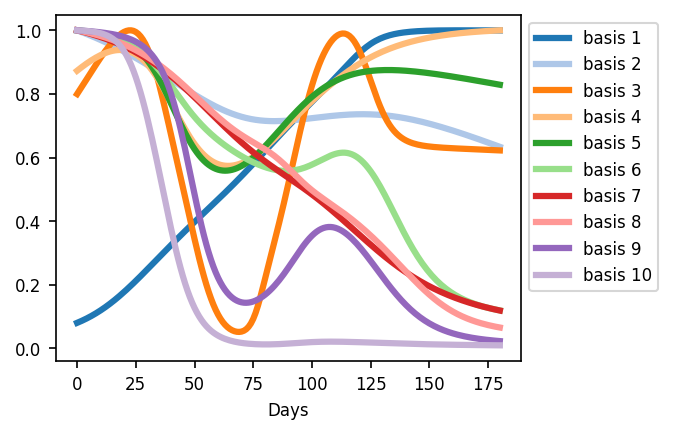

In [57]:
basis_a = get_basis(trajectory_model_a, guide_a, clone_patterns_padded_allo_train.numpy(), times_a)

colors = sns.color_palette("tab20", 20)

fig, ax = plt.subplots(1,1, figsize=(4,3), dpi = 150)
plt.rcParams.update({'font.size': 8})
ax = _plot_basis(basis_a, colors)
plt.xlabel("Days")
plt.legend(bbox_to_anchor=(1,1),loc = "upper left")
plt.show()

You obtain all the results through the samples variable.
- samples['_RETURN']: Reconstructions of the patterns
- samples['beta']: Returns the beta mean and std
- samples['obs']: provides the original data

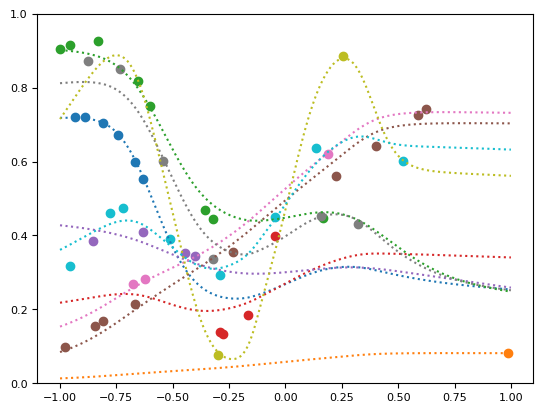

In [58]:
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

m = 10
palette = sns.color_palette(n_colors=m)
for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
    plt.scatter(times_padded, clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette[i])
    # plt.plot(times, new_functions_ds[0,idx].detach().numpy(), color = palette[i])
    plt.plot(times_padded, reconstruction.numpy()[idx,:], ls = ':', color = palette[i])
plt.ylim([0,1])
plt.show()

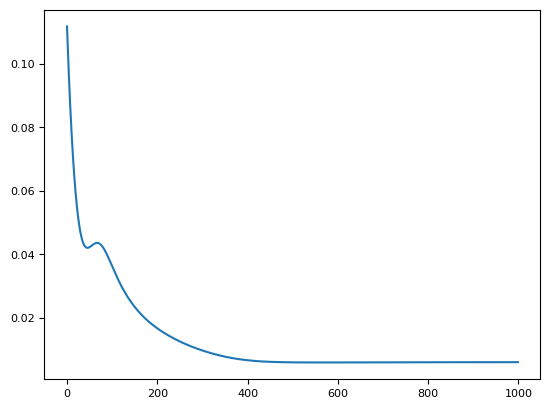

In [59]:
clear_val_params()

adam = pyro.optim.ClippedAdam({"lr": .01})
elbo = Trace_ELBO()
    
model_val = BasisDecomposition_Evaluate(
            trajectory_model_a._last_basis.detach(),
            clone_patterns_padded_allo_val.shape[0],
            beta_prior=beta_prior,
            normalized_mode = True
            
        )
guide_val = get_inference_guide(model_val, InferenceMode.POINT_ESTIMATE)
svi_val = SVI(model_val, guide_val, adam, loss=elbo)
val_loss = []
loss_val = 0
for _ in range(1000):
    loss_val = svi_val.step(torch.FloatTensor(times_padded), torch.FloatTensor(clone_patterns_padded_allo_val.numpy()))
    reconstruction_val = ((model_val._last_patterns - clone_patterns_padded_allo_val) ** 2).nanmean().item()
    val_loss.append(reconstruction_val)


plt.plot(val_loss)


samples = []
predictive = Predictive(
        model_val, guide=guide_val, num_samples=10, return_sites=("beta_val","_RETURN",  "obs_val")
    )
samples = predictive(times_a, clone_patterns_padded_allo_val)#, None)

clone_scales = model_val.gene_scales
samples = summary(samples)

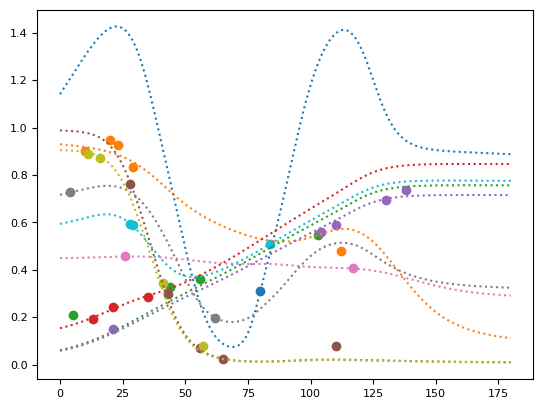

In [60]:
reconstruction_val = samples["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()

m = 10
palette = sns.color_palette(n_colors=m)
for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_val))
    plt.scatter(np.arange(0,181), clone_patterns_padded_allo_val[idx,:].detach().numpy(), color = palette[i])
    # plt.plot(times, clone_patterns[0,idx,:].detach().numpy(), color = palette[i])
    plt.plot(np.arange(0,181), reconstruction_val.numpy()[idx,:], ls = ':', color = palette[i])
plt.show()

0.9691255688667297
(2, 10923)


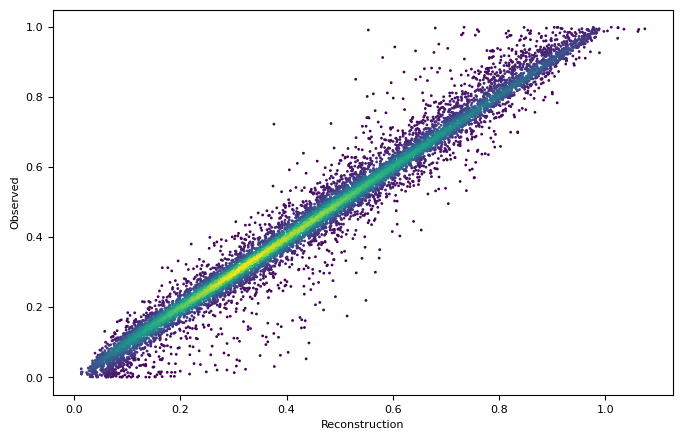

0.907993733882904


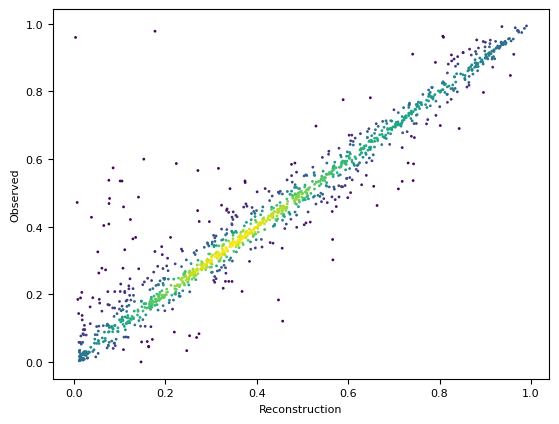

In [61]:
# Reconstructed values should lie on y=x line if the model is performing well

reconstruction_val = samples["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

train_R2 = r2_score(clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten(),reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten())
print(train_R2)

d = np.vstack([reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())]])
kernel = st.gaussian_kde(d)
values = kernel(d)
print(d.shape)
fig, ax = plt.subplots(1,1, figsize = (8,5))

m = 5
ax.scatter(reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], s = 1,
            c = values)

ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")

plt.show()


val_R2 = r2_score(clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten(),reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten())
print(val_R2)

d = np.vstack([reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())]])
kernel = st.gaussian_kde(d)
values = kernel(d)

m = 5
plt.scatter(reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], s = 1,
            c = values)

plt.ylabel("Observed")
plt.xlabel("Reconstruction")

plt.show()

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


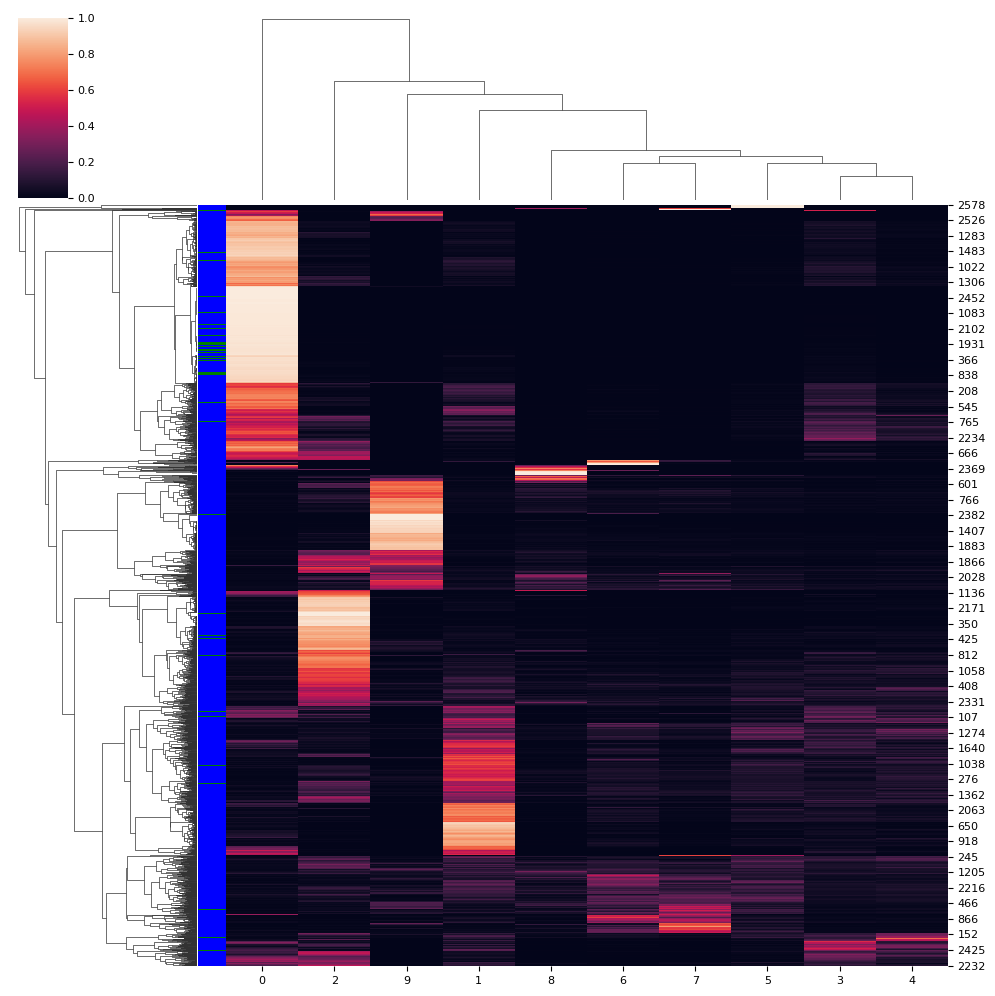

In [62]:
train_labels, val_labels = labels[train_a_idx], labels[val_a_idx]
final_labels = np.concatenate([train_labels, val_labels], axis = 0)

all_betas = np.concatenate([samples_a['beta']['mean'].squeeze(), samples['beta_val']['mean'].squeeze()], axis = 0)
sns.clustermap(all_betas, row_colors=final_labels)

As seen above we are for the most part able to reconstruct the patterns and detect the separation between different groups with different proportions of the toy basis patterns. If repeated with reducing the sparsity of the data we would see stronger seperation and cleaner patterns.